# Parameters from Gaussian Mixture Model

## Used libraries

In [1]:
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
main_path = '/content/drive/MyDrive/AzONet_New_145'

## Seaborn

In [4]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
    "figure.dpi": 300,           # Default DPI for new figures
    "savefig.dpi": 300,          # DPI when saving figures

    # Font settings
    "font.family": "sans-serif",     # Universal font family
    "font.size": 11,                   # Base font size

    # Title and label sizes
    "axes.titlesize": 16,             # Axis title size
    "axes.titleweight": "bold",       # Axis title weight
    "axes.labelsize": 14,             # Axis label size
    "axes.labelweight": "semibold",   # Axis label weight

    # -------------------------------------------------

    # Tick LABEL sizes (text next to ticks)
    "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
    "ytick.labelsize": 11,       # Size of y-axis tick labels

    # Tick MARK sizes (physical marks on axes)
    "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
    "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

    # Additional tick parameters you might want to use:
    "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
    "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

    # Tick WIDTH (thickness)
    "xtick.major.width": 1,      # Width/Thickness of major ticks
    "ytick.major.width": 1,      # Width/Thickness of major ticks

    # Tick PADDING (distance from label to tick)
    "xtick.major.pad": 3.5,      # Padding between x-tick and label
    "ytick.major.pad": 3.5,      # Padding between y-tick and label

    # Tick DIRECTIONS
    "xtick.direction": "out",    # "in", "out", or "inout"
    "ytick.direction": "out",    # Points outward from axis

    # Tick COLORS
    "xtick.color": "black",      # Color of x-axis ticks and labels
    "ytick.color": "black",      # Color of y-axis ticks and labels

    # MINOR ticks (for more granular scales)
    "xtick.minor.visible": False,  # Show minor x-ticks
    "ytick.minor.visible": False,  # Show minor y-ticks

    # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
    "xtick.top": False,          # Show ticks on top of plot
    "xtick.bottom": True,        # Show ticks on bottom (default: True)
    "ytick.left": True,          # Show ticks on left (default: True)
    "ytick.right": False,        # Show ticks on right

    # ---------------------------------

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,
    "legend.framealpha":0.9,

    # Figure title (for suptitle)
    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    # ----------------------------------

    # Figure border
    #"figure.edgecolor": "black",
    #"figure.frameon": True,
    #"figure.linewidth": 2.0,

    # Axes borders (spines)
    "axes.linewidth": 1.0,           # Width of axis lines
    "axes.edgecolor": "black",       # Color of axis lines

    # Individual spine control via rcParams
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,

    # ----------------------------
    # Patch properties (for histograms, bars, kde fills, etc.)
    "patch.linewidth": 1.5,           # Default linewidth for patches
    "patch.edgecolor": "black",       # Default edge color
    "patch.facecolor": "blue",        # Default fill color (careful with this!)
    "patch.force_edgecolor": True,    # Always show edges

    "axes.grid": False,           # Turn off grid completely

})

## Bin to simulate from

In [5]:
bint = 2

In [6]:
table_data = []

## Main Data

In [7]:
param = np.load(main_path + '/notebooks/2_de/bins/region_{}.npy'.format(bint))

In [8]:
param.shape

(46, 12)

In [9]:
param[0]

array([6.25493118e+02, 1.24136698e+01, 1.44004202e+01, 3.26239401e+00,
       1.19859952e+05, 9.69790134e+06, 5.00005765e-01, 3.15409757e+02,
       9.50659136e-03, 1.29690230e+01, 3.63404400e+02, 3.96905779e+26])

## Gaussian Mixture Model

In [10]:
from sklearn.mixture import GaussianMixture

In [11]:
def GMM(data, max_gaussians: int = 10):
    data = data.reshape(-1, 1)

    bic_values = []
    n_components_range = range(1, max_gaussians+1) # Consider 10 Gaussians to Model it

    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=1360)
        gmm.fit(data)
        bic_values.append(gmm.bic(data))


    # Get the optimal number of components
    optimal_n_components = n_components_range[np.argmin(bic_values)]
    print(f"Óptimo número de componentes: {optimal_n_components}")

    # Fit the GMM with the optimal number of components
    gmm_optimal = GaussianMixture(n_components=optimal_n_components, covariance_type='full', random_state=1360)
    gmm_optimal.fit(data)


    # # Access the model parameters
    means = gmm_optimal.means_
    covariances = gmm_optimal.covariances_
    weights = gmm_optimal.weights_

    # Print the parameters
    print("Centroides:")
    print(means)
    print("\nCovarianzas")
    print(covariances)
    print("\nPesos")
    print(weights)

    # If you want to see if the model converged
    print("\nCovergencia:", gmm_optimal.converged_)


    #
    std_devs = np.sqrt(np.diagonal(covariances, axis1=1, axis2=2))
    print('\nSTD:\n',std_devs)

    fwhm =  (2 * np.sqrt(2 * np.log(2) ) ) *  np.sqrt(np.diagonal(covariances, axis1=1, axis2=2))
    print('\nFWHM:\n',fwhm)

    table_data.append(
        [ means, std_devs, weights ]
    )

    return [
        #optimal_n_components,
        means,
        std_devs,
        #covariances,
        weights,
        np.min(data),
        np.max(data),
        gmm_optimal
    ]

In [12]:
def GMM_Model(t_values, means, std_devs, weights, min_value, max_value, score, n:int = 5000):

    _data = []
    for i in range(means.shape[0]):
        _data.append(np.random.normal( means[i], std_devs[i], int(n*weights[i])) )

    _data = np.concatenate(_data)
    if len(t_values) != 0:
        _data = _data[ _data>= t_values[0] ]
        _data = _data[ _data <= t_values[1] ]
    else:
        _data = _data[ _data>= min_value ]
        _data = _data[ _data <= max_value ]

    return _data, score


In [13]:
def GMM_pipeline(data, max_gaussians: int = 10, t_values = []):
    _dist = GMM(
        data= data,
        max_gaussians = max_gaussians,
    )

    simulated_data, gmm_optimal = GMM_Model(t_values, *_dist)

    return simulated_data

## Thickness

In [14]:
t_list = [100, 250, 600, 950, 1100, 1500]

In [15]:
thickness = GMM_pipeline(
    data = param[:, 0],
    max_gaussians= 3,
    t_values= [
        t_list[bint],
        t_list[bint+1]
    ]
    )

Óptimo número de componentes: 1
Centroides:
[[797.39098294]]

Covarianzas
[[[5665.78742732]]]

Pesos
[1.]

Covergencia: True

STD:
 [[75.27142504]]

FWHM:
 [[177.2506605]]


In [16]:
np.max(thickness), np.min(thickness)

(np.float64(949.9649259496728), np.float64(600.5804251861498))

In [17]:
table_data

[[array([[797.39098294]]), array([[75.27142504]]), array([1.])]]

## R1

In [18]:
r1 = GMM_pipeline(
    data = param[:, 1],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[14.9720961 ]
 [40.88446126]]

Covarianzas
[[[ 44.11942303]]

 [[105.02124891]]]

Pesos
[0.71744433 0.28255567]

Covergencia: True

STD:
 [[ 6.64224533]
 [10.24798755]]

FWHM:
 [[15.64129245]
 [24.13216651]]


In [19]:
table_data[1]

[array([[14.9720961 ],
        [40.88446126]]),
 array([[ 6.64224533],
        [10.24798755]]),
 array([0.71744433, 0.28255567])]

## R2

In [20]:
r2 = GMM_pipeline(
    data = param[:, 2],
    max_gaussians= 3,
    )

Óptimo número de componentes: 3
Centroides:
[[15.70928918]
 [36.63833245]
 [73.74261628]]

Covarianzas
[[[6.42445649e+01]]

 [[8.61381720e+01]]

 [[1.00000000e-06]]]

Pesos
[0.66368401 0.31457687 0.02173912]

Covergencia: True

STD:
 [[8.01527073e+00]
 [9.28106524e+00]
 [1.00000000e-03]]

FWHM:
 [[1.88745202e+01]
 [2.18552385e+01]
 [2.35482005e-03]]


In [21]:
pick_one = lambda x: np.random.choice(x) # This function inputs an array and returns a random element of that array

In [22]:
r1.shape, r2.shape

((4746,), (4639,))

## Absortion Coefficients

In [23]:
# Alpha
alpha = GMM_pipeline(
    data = param[:, 8],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[0.00946969]
 [0.00312777]]

Covarianzas
[[[6.76164493e-06]]

 [[3.18181132e-06]]]

Pesos
[0.48464876 0.51535124]

Covergencia: True

STD:
 [[0.00260032]
 [0.00178376]]

FWHM:
 [[0.00612328]
 [0.00420044]]


In [24]:
# beta
beta = GMM_pipeline(
    data = param[:, 9],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[11.96852466]
 [ 9.58211058]]

Covarianzas
[[[0.31259469]]

 [[0.45333653]]]

Pesos
[0.27139459 0.72860541]

Covergencia: True

STD:
 [[0.55910168]
 [0.6733027 ]]

FWHM:
 [[1.31658384]
 [1.5855067 ]]


In [25]:
# lambda
lamda = GMM_pipeline(
    data = param[:, 10],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[360.53264735]]

Covarianzas
[[[72.04067991]]]

Pesos
[1.]

Covergencia: True

STD:
 [[8.48767812]]

FWHM:
 [[19.98695458]]


## Sellmeier Coefficients

The refractive index must be between $[1.8, 2.1]$, and the refractive index is given by:
$$n^{2}(\lambda) = A + \frac{B\lambda^{2}}{\lambda^{2} - C^{2}} + \frac{D\lambda^{2}}{\lambda^{2} - E^{2}}$$
Generate the Sellmeier Coefficients:

In [26]:
# A
A = GMM_pipeline(
    data = param[:, 3],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[3.24658914]
 [3.73298769]]

Covarianzas
[[[9.67368648e-05]]

 [[1.43372400e-01]]]

Pesos
[0.70415879 0.29584121]

Covergencia: True

STD:
 [[0.00983549]
 [0.37864548]]

FWHM:
 [[0.02316081]
 [0.89164197]]


In [27]:
B = GMM_pipeline(
    data = param[:, 4],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[1381233.40600688]]

Covarianzas
[[[2.92448297e+11]]]

Pesos
[1.]

Covergencia: True

STD:
 [[540784.88976433]]

FWHM:
 [[1273451.0984669]]


In [28]:
C = GMM_pipeline(
    data = param[:, 5],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[9074314.63841236]
 [2079460.24302183]]

Covarianzas
[[[1.25806557e+13]]

 [[6.83508278e+11]]]

Pesos
[0.16855834 0.83144166]

Covergencia: True

STD:
 [[3546922.0083312 ]
 [ 826745.59461693]]

FWHM:
 [[8352363.04337974]
 [1946837.09834497]]


In [29]:
D = GMM_pipeline(
    data = param[:, 6],
    max_gaussians= 3,
    )

Óptimo número de componentes: 3
Centroides:
[[0.58155676]
 [3.16534891]
 [1.33539941]]

Covarianzas
[[[1.41571239e-02]]

 [[1.00000000e-06]]

 [[9.15920457e-03]]]

Pesos
[0.86955023 0.02173913 0.10871064]

Covergencia: True

STD:
 [[0.11898371]
 [0.001     ]
 [0.09570373]]

FWHM:
 [[0.28018523]
 [0.00235482]
 [0.22536507]]


In [30]:
E = GMM_pipeline(
    data = param[:, 7],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[317.20039138]
 [153.25177409]]

Covarianzas
[[[395.27981625]]

 [[172.91953062]]]

Pesos
[0.95652174 0.04347826]

Covergencia: True

STD:
 [[19.88164521]
 [13.1498871 ]]

FWHM:
 [[46.81769667]
 [30.96561772]]


In [31]:
x = np.linspace(190e-9, 1101e-9, 911)

def refractive_index(x, A, B, C, D, E):

    n = np.sqrt(A + (B*x**2)/(x**2 - C**2 + 1e-6) + (D*x**2)/(x**2 - E**2 + 1e-6))  # Get the n
    #print(n.shape)

    return ( np.min(n), np.max(n) )


In [32]:
_A, _B, _C, _D, _E = pick_one(A), pick_one(B), pick_one(C), pick_one(D), pick_one(E)

_min, _max = refractive_index(x, _A, _B, _C, _D, _E)
_min, _max

(np.float64(1.8024461788642325), np.float64(1.8024461788642325))

The refractive is in the following range:
$$1.8 <  n < 2.1 $$

In [33]:
ABCDE = []

while len(ABCDE) < 3000:

    _A, _B, _C, _D, _E = pick_one(A), pick_one(B), pick_one(C), pick_one(D), pick_one(E)

    _min, _max = refractive_index(x, _A, _B, _C, _D, _E)[0] , refractive_index(x, _A, _B, _C, _D, _E)[1]

    if (_min >= 1.8 and  _max <= 2.1):
        ABCDE.append( (_A, _B, _C, _D, _E)  )

In [34]:
len(ABCDE)

3000

In [35]:
ABCDE = np.array(ABCDE)
ABCDE.shape

(3000, 5)

In [36]:
A, B, C, D, E = ABCDE.T
A.shape

(3000,)

## Ne

In [37]:
ne = GMM_pipeline(
    data = param[:, 11],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[2.77842519e+26]
 [1.04324687e+26]]

Covarianzas
[[[1.61797644e+52]]

 [[2.26881193e+51]]]

Pesos
[0.26851347 0.73148653]

Covergencia: True

STD:
 [[1.27199703e+26]
 [4.76320473e+25]]

FWHM:
 [[2.9953241e+26]
 [1.1216490e+26]]


## Table

In [38]:
from prettytable import PrettyTable

In [39]:
names = ['r [nm]',
         r'$\sigma_{1} [nm]$', r'$\sigma_{2}$ [nm]',
         'A', 'B', 'C [nm]', 'D', 'E [nm]',
         r'$\alpha_{0}$ [nm]$^{-1}$', r'$\beta$ [eV]$^{-1}$', r'$\lambda_{g}$ [nm]',
         r'$n_{e}$ [nm]$^{-3}$',
        ]

In [40]:
table_data[1]

[array([[14.9720961 ],
        [40.88446126]]),
 array([[ 6.64224533],
        [10.24798755]]),
 array([0.71744433, 0.28255567])]

In [41]:
def to_str_good(array, pesos = False):
    txt = ''
    if pesos == False:
        if array.shape == (1,1):
            txt = '{:.3e}'.format(array[0, 0])
        elif array.shape == (2,1):
            txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}'.format(array[1, 0])
        else:
            txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}, '.format(array[1, 0]) + '{:.3e}'.format(array[2, 0])

    if pesos:
        if array.shape == (1,1):
            txt = '{:.1f}'.format(array[0, 0])
        elif array.shape == (2,1):
            txt = '{:.1f}, '.format(array[0, 0]) + '{:.1f}'.format(array[1, 0])
        else:
          txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}, '.format(array[1, 0]) + '{:.3e}'.format(array[2, 0])

    return txt

In [42]:
table_data = [
    table_data[0], # Espesor,
    table_data[1], # R1
    table_data[2], # R2
    table_data[6], #A,
    table_data[7], #B,
    table_data[8], #C,
    table_data[9], #D,
    table_data[10], #E,
    table_data[3], #Alpha,
    table_data[4], #Beta,
    table_data[5], #LambdaG,
    table_data[11], #ne
]

In [43]:
table = PrettyTable()

table.field_names = ["", r"Centroides $\mu_{i}$", r'Desviaciones $\delta_{i}$', r'Pesos $P_{i}$']

j = 0
for i in table_data:
    table.add_row([names[j],
                   to_str_good(i[0]),
                   to_str_good(i[1]),
                   to_str_good(np.expand_dims(i[2], axis = -1), pesos = True)
                  ]
                  )
    j +=1
print(table)


+--------------------------+---------------------------------+---------------------------------+---------------------------------+
|                          |       Centroides $\mu_{i}$      |    Desviaciones $\delta_{i}$    |          Pesos $P_{i}$          |
+--------------------------+---------------------------------+---------------------------------+---------------------------------+
|          r [nm]          |            7.974e+02            |            7.527e+01            |               1.0               |
|    $\sigma_{1} [nm]$     |       1.497e+01, 4.088e+01      |       6.642e+00, 1.025e+01      |             0.7, 0.3            |
|    $\sigma_{2}$ [nm]     | 1.571e+01, 3.664e+01, 7.374e+01 | 8.015e+00, 9.281e+00, 1.000e-03 | 6.637e-01, 3.146e-01, 2.174e-02 |
|            A             |       3.247e+00, 3.733e+00      |       9.835e-03, 3.786e-01      |             0.7, 0.3            |
|            B             |            1.381e+06            |            5.408e+05

In [44]:
latex_code = table.get_latex_string()
print("\n--- Generated LaTeX Code ---")
print(latex_code)


--- Generated LaTeX Code ---
\begin{tabular}{cccc}
 & Centroides $\mu_{i}$ & Desviaciones $\delta_{i}$ & Pesos $P_{i}$ \\
r [nm] & 7.974e+02 & 7.527e+01 & 1.0 \\
$\sigma_{1} [nm]$ & 1.497e+01, 4.088e+01 & 6.642e+00, 1.025e+01 & 0.7, 0.3 \\
$\sigma_{2}$ [nm] & 1.571e+01, 3.664e+01, 7.374e+01 & 8.015e+00, 9.281e+00, 1.000e-03 & 6.637e-01, 3.146e-01, 2.174e-02 \\
A & 3.247e+00, 3.733e+00 & 9.835e-03, 3.786e-01 & 0.7, 0.3 \\
B & 1.381e+06 & 5.408e+05 & 1.0 \\
C [nm] & 9.074e+06, 2.079e+06 & 3.547e+06, 8.267e+05 & 0.2, 0.8 \\
D & 5.816e-01, 3.165e+00, 1.335e+00 & 1.190e-01, 1.000e-03, 9.570e-02 & 8.696e-01, 2.174e-02, 1.087e-01 \\
E [nm] & 3.172e+02, 1.533e+02 & 1.988e+01, 1.315e+01 & 1.0, 0.0 \\
$\alpha_{0}$ [nm]$^{-1}$ & 9.470e-03, 3.128e-03 & 2.600e-03, 1.784e-03 & 0.5, 0.5 \\
$\beta$ [eV]$^{-1}$ & 1.197e+01, 9.582e+00 & 5.591e-01, 6.733e-01 & 0.3, 0.7 \\
$\lambda_{g}$ [nm] & 3.605e+02 & 8.488e+00 & 1.0 \\
$n_{e}$ [nm]$^{-3}$ & 2.778e+26, 1.043e+26 & 1.272e+26, 4.763e+25 & 0.3, 0.7 \\
\

## Save the data

In [45]:
names = [
    'thickness',
    'r1', 'r2',
    'A', 'B', 'C', 'D', 'E',
    'alpha', 'beta', 'lambda',
    'ne'
]

values = [
    thickness,
    r1, r2,
    A, B, C, D, E,
    alpha, beta, lamda,
    ne
]

In [46]:
k = 0
for v in values:
    np.save(
        main_path+'/notebooks/3_data_simulation/data/R{}/{}'.format(bint+1, names[k]),
        v
    )
    k+=1

# Dataset Generation

The next function generates the Transmitance Spectrum

In [47]:
# Archivo para obtener los valores de transmitancia del vidrio

#print(t_v[:,0][0])
def modelo_transmitancia(x,
                         d,
                         rugo_1, rugo_2,
                         A, B, C, D, E,
                         alpha, beta, gamma,
                         ne):
    """
    x = longitud de onda
    d = espesor de la película
    t_vidrio = transmitancia del vidrio, valor experimental
    rugo_1 = rugosidad_1
    rugo_2 = rugosidad_2
    sellmeier = es el arreglo donde van a estar los coeficientes de la ecuacion de Sellmeier
    absorcion =  es el arreglo donde se van a guardar los coeficientes de la ecuacion de la absorcion
    ne = concentracion de electrones

    """
    # Constantes utilizadas

    c = 3e8 # Velocidad de la luz

    mu = 3.90e-4 # Movilidad

    df = pd.read_csv('/content/drive/MyDrive/AzONet_New_161/experimental_samples/Background_data/TexpglassO.txt', sep = "\t", header = 0)
    t_v = df.values

    sellmeier = [A, B, C, D, E]

    absorcion = [alpha, beta, gamma]

    #ome_pla = np.sqrt(3182.61/0.417)*ne #Frecuencia de Plasma

    # Funciones

    def frecuencia(x):

        omega = 2 * np.pi * c * 1e9 / x

        return omega

    def gamma_f(x):

        gama = 2.8e11*x

        return gama

    def e1f_f(omega,gama,ne):

        return -(3182.61*ne)/(omega**2 + gama**2)

    def e2f_f(omega,gama,ne):

        return (3182.61 * ne * gama)/(omega * (omega**2 + gama**2))

    def e1b_f(x,sellmeier):
        # A = 2.0065
        # B = 1.574e6
        # C = 1e7
        # D = 1.5868
        # E = 260.63
        return sellmeier[0] + (sellmeier[1] * x**2)/(x**2 - sellmeier[2]**2 + 1e-6) + (sellmeier[3] * x**2)/(x**2 - sellmeier[4]**2 + 1e-6)

    def e2b_f(x):

        return 0.0

    def e1_f(e1f,e1b):

        return e1f + e1b

    def e2_f(e2f,e2b):

        return e2f + e2b

    def ng_f(t_v):
        """
        t_v transmitancia del vidrio
        """
        return (1/t_v) + np.sqrt(1/(t_v**2) - 1)

    def n_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(e1 + np.sqrt(e1**2 + e2**2)) + 1e-6

    def kapa_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(-e1 + np.sqrt(e1**2 + e2**2))

    def neff1_f(n):

        return np.sqrt((1/2) * (n**2 + 1))

    def T1_f(neff1,x,n,rugo_1):

        return np.exp(-0.5 * (2 * np.pi * rugo_1 * (neff1 - 1))**2 / x**2) * (n/1) * (4/(n + 1)**2)

    def T2_f(neff1,x,ng,n,rugo_2):

        return np.exp(-0.5 * (1/x**2) * (2 * np.pi * rugo_2 * (neff1 - 1))**2) * (ng/n) * 4 * (n**2) * (1/(n + ng)**2)

    def T3_f(ng):

        return (1/ng) * 4 * ng**2 * (1/(1 + ng)**2)

    def R1_f(n,x,rugo_1):

        return np.exp(-2 * (2 * np.pi * rugo_1 * n)**2 * (1/x)**2) * (n - 1)**2 * (1/(n + 1))**2

    def R2_f(n,x,ng,rugo_2):

        return np.exp(-2 * (2 * np.pi * rugo_2 * n)**2 * (1/x)**2) * (n - ng)**2 * (1/(n + ng))**2

    def R21_f(n,ng):

        return (n - ng)**2 * (1/(n + ng)**2)

    def R3_f(ng):

        return (ng - 1)**2 * (1/(ng + 1)**2)

    def phi_f(n,d,x):

        return 4 * np.pi * n * d * (1/x)

    def alfa_f(kapa,x,absorcion):
        #alpha_0 = 2.5e-3
        #beta = 9.8
        #lambdag = 363

        return kapa * 4 * np.pi * (1/x) + absorcion[0] * np.exp(1240 * absorcion[1] * ((1/x) - (1/absorcion[2])))

    def Tf_f(T1,T2,alfa,d,phi,R1,R2):

        exp1 = np.exp(np.clip(-alfa * d, -700, 700))
        exp2 = np.exp(np.clip(-2 * alfa * d, -700, 700))

        denominator = 1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * exp1 + R1 * R2 * exp2
        result = (T1 * T2) * exp1 / denominator

        return result
        #(T1 * T2) * np.exp(-alfa * d) / (1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * np.exp(-alfa * d) + R1 * R2 * np.exp(-2 * alfa * d))

    def T_f(T3,R21,R3,Tf):

        return 1.0 * ((T3 / (1 - R21 * R3)) * Tf * 100)

    def N_f(T1,R1):

        return T1 + k

    # Realizamos los calculos en cadena para obtener la transmitancia del modelo.

    omega = frecuencia(x) # Check

    gama = gamma_f(x) # Check

    e1f = e1f_f(omega,gama,ne)

    e2f = e2f_f(omega,gama,ne)

    e1b = e1b_f(x,sellmeier)

    e2b = e2b_f(x)

    e1 = e1_f(e1f,e1b)

    e2 = e2_f(e2f,e2b)

    ng = ng_f(t_v[:,1]) # Al ser un df, se transforma en un arreglo donde tomo solo la segunda columna

    #nswanep = nswanep(e1b[0])

    n = n_f(e1,e2)

    kapa = kapa_f(e1,e2)

    neff1 = neff1_f(n)

    T1 = T1_f(neff1,x,n,rugo_1)

    T2 = T2_f(neff1,x,ng,n,rugo_2)

    T3 = T3_f(ng)

    R1 = R1_f(n,x,rugo_1)

    R2 = R2_f(n,x,ng,rugo_2)

    R21 = R21_f(n,ng)

    R3 = R3_f(ng)

    phi = phi_f(n,d,x)

    alfa = alfa_f(kapa,x,absorcion)

    Tf = Tf_f(T1,T2,alfa,d,phi,R1,R2)

    T = T_f(T3,R21,R3,Tf)

    # Input   x, t_vidrio, d, rugo_1, rugo_2, sellmeier, absorcion, ne / x longitud de onda
    # Output  T, d, rugo_1, rugo_2, sellmeier, absorcion, ne / T transmitancia
    if np.isnan(T).any():
        print('NAN: T')

    return np.nan_to_num(T, nan=1e-6) , d, rugo_1, rugo_2, sellmeier, absorcion, ne

In [48]:
x = np.linspace(190,1101,911)

_final = []

for i in tqdm(range( int( 240e3 ) ), desc = 'Sample Generation'):  #400e3

    d = pick_one(thickness)

    rugo_1, rugo_2 = pick_one(r1), pick_one(r2)

    sellmeier = [pick_one(A),
                pick_one(B),
                pick_one(C),
                pick_one(D),
                pick_one(E)
               ]

    absorcion = [pick_one(alpha),
                 pick_one(beta),
                 pick_one(lamda),
                ]

    _ne = pick_one(ne)

    T_ini, d_ini, rugo_1_ini, rugo_2_ini, sellmeier_ini, absorcion_ini, ne_ini = modelo_transmitancia(x, d, rugo_1, rugo_2, *sellmeier, *absorcion, _ne)

    if np.any(np.isnan(np.array(T_ini))):
        continue

    df = pd.DataFrame({
        'Espectro': [T_ini],
        'Espesor': d_ini,
        'R1': rugo_1_ini,
        'R2': rugo_2_ini,
        'Sellmeier': [sellmeier_ini],
        'Absorcion': [absorcion_ini],
        'ne': ne_ini
    })

    _final.append(df)


Sample Generation: 100%|██████████| 240000/240000 [14:23<00:00, 277.79it/s]


In [49]:
df_final = pd.concat(_final, ignore_index = True)

In [50]:
df_final.head()

,Espectro,Espesor,R1,R2,Sellmeier,Absorcion,ne
0,"[1.6893206160205285e-306, 1.5072822541520556e-...",826.822463,27.525009,35.369430,"[3.6869091293363105, 2199353.539403867, 290436...","[0.005211398644591017, 12.06519926387475, 373....",5.940468e+25
1,"[1.975518928101571e-306, 1.757273243891216e-30...",768.711410,10.495340,22.256547,"[3.263443919913337, 435308.8104676339, 2620301...","[0.0019256376486911319, 9.142342230213526, 366...",3.774002e+26
2,"[1.7762320958104923e-306, 1.5828780353815324e-...",816.838658,13.618397,41.827121,"[3.2523951218862104, 1430514.3309039029, 22521...","[0.011247061098902857, 8.796835455311172, 367....",1.507403e+26
3,"[1.9316688166780458e-306, 1.718783304704931e-3...",728.725320,9.605842,27.543482,"[3.24442950847788, 1152617.67452638, 1185863.4...","[0.008309038039764096, 9.670042294213424, 374....",1.714286e+26
4,"[1.9013730644653682e-306, 1.6923332741093664e-...",825.613058,20.813286,25.598009,"[3.2498876912129435, 1924107.8032241757, 13030...","[0.0008705623054784573, 10.567069008289387, 37...",2.640268e+26


In [51]:
# Revolvemos el df_final
df_final = df_final.sample(frac=1).reset_index(drop = True)

In [52]:
df_final.head()

,Espectro,Espesor,R1,R2,Sellmeier,Absorcion,ne
0,"[1.6053469407287434e-306, 1.432439408686154e-3...",682.609332,53.265489,12.442540,"[3.246173523512041, 1264898.7387269824, 446962...","[0.010973495372464073, 11.938553862431114, 361...",4.687825e+26
1,"[1.989871597310243e-306, 1.7695236451087373e-3...",832.016890,13.102736,22.022980,"[3.2524618652854485, 1738330.8123601119, 89003...","[0.009601575425149828, 11.902367262973714, 349...",1.560063e+26
2,"[1.9341966155214395e-306, 1.7210603665621834e-...",680.694116,19.813093,21.474836,"[3.2485315217287454, 1867594.1588975452, 16218...","[0.006397950768843317, 11.904043665942597, 357...",7.300987e+25
3,"[1.9021329336863415e-306, 1.6930565557407227e-...",839.861049,12.995561,30.081049,"[3.2645153788722987, 1721464.5507343067, 26502...","[0.0034218535280304096, 9.89853206261764, 361....",1.123719e+26
4,"[1.9047345197500852e-306, 1.69539073876628e-30...",756.650185,21.910294,20.290508,"[3.5124756004726088, 1870348.9973267205, 16457...","[0.008413581780272331, 9.459055120575746, 371....",8.989987e+25


# Graphics

In [53]:
def plot_unico(x,y):

  plt.figure(figsize=(10,6))
  plt.ylabel('Transmitancia %')
  plt.xlabel('Longitud de Onda [nm]')
  plt.scatter(x,y,s = 5)
  plt.show()

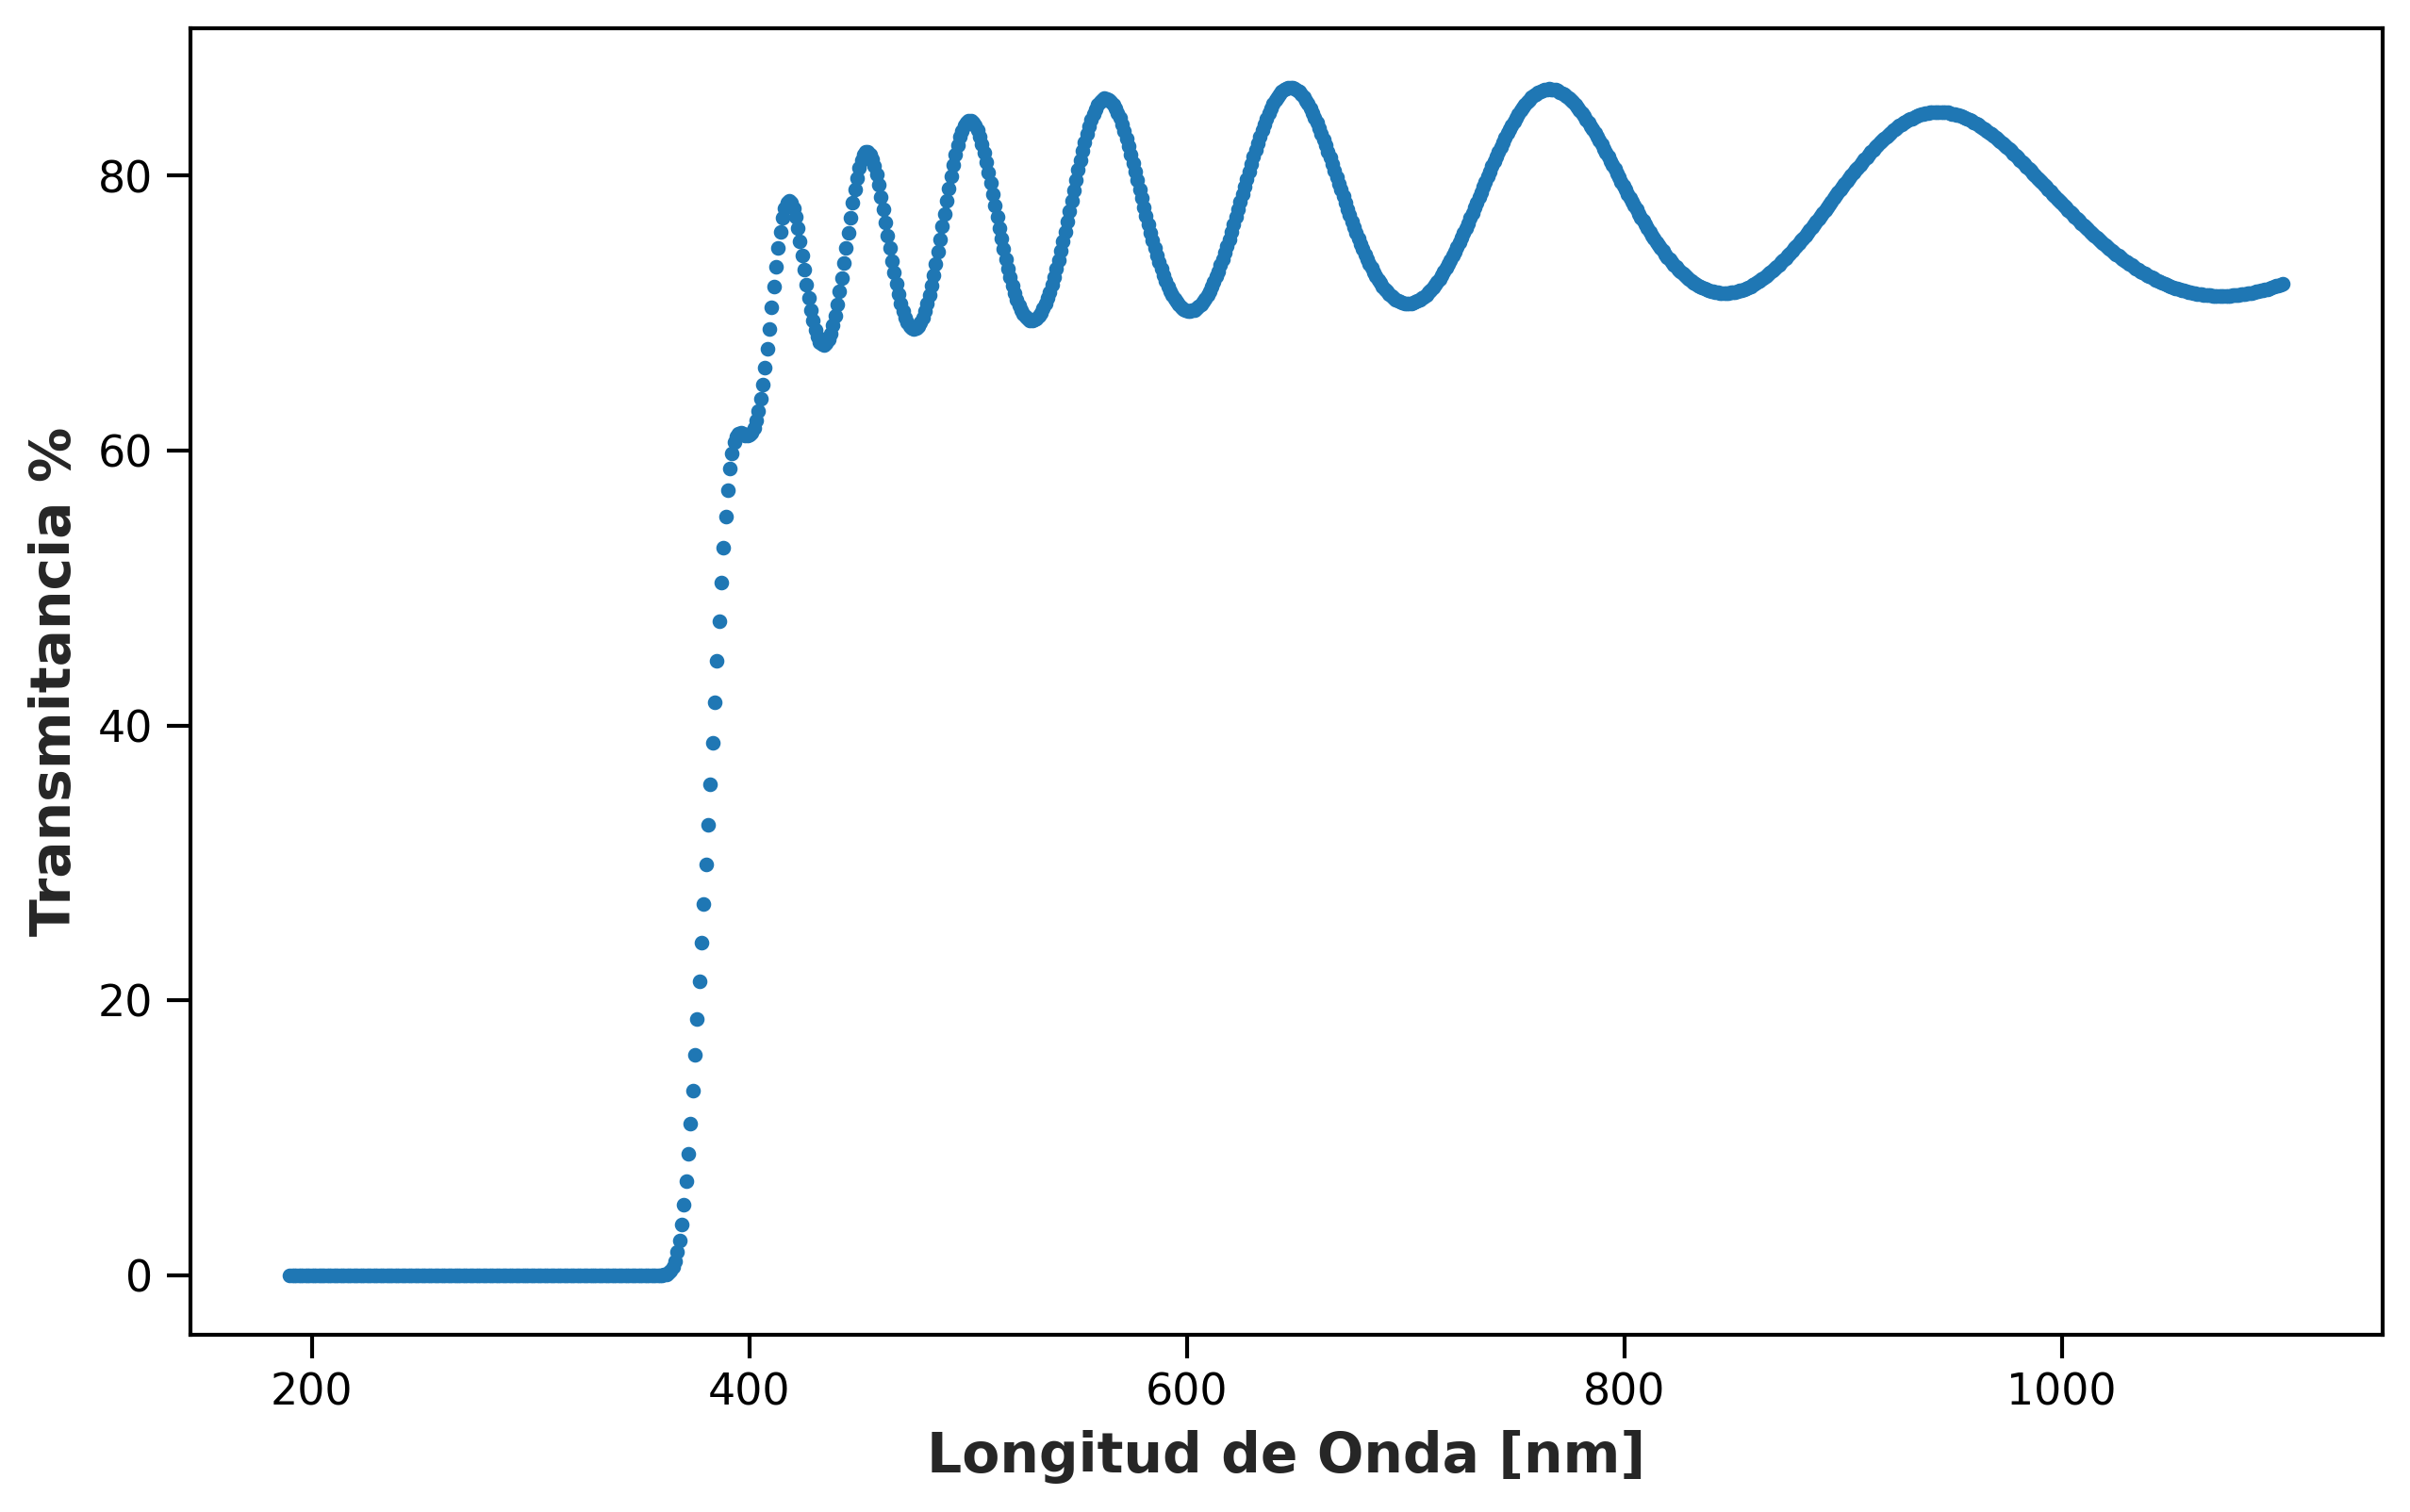

In [54]:
n = random.randint(0, df_final.shape[0]-1)
plot_unico(x, df_final['Espectro'][n])

# Save DF

In [55]:
df_final.shape

(240000, 7)

In [56]:
df_final.to_parquet(main_path + '/notebooks/3_data_simulation/NewDataAzONetV2/bin_{}.parquet'.format(bint), index = False)